# 6-A1 作業：設計自己的存幣方式

[![在 Colab 開啟](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/finlab-python/hahow-crypto-course/blob/main/6-A1_puell_multiple.ipynb)

**對應影片**：第 6 章 作業 6-A1【基本面策略】用 Puell Multiple 找到價格低點

**和影片的差異**

- 新增的起始筆記本：Puell Multiple 與「每月定額」的比較基準已經算好，只要改 `my_rule`。

6-2 的策略風險較低，但沒有跑贏單純持有比特幣。設計一個你自己的存幣規則，
和「每月定額買進」比較看看！

In [1]:
%pip install -q finlab_crypto==0.3.0

Note: you may need to restart the kernel to use updated packages.


<Axes: xlabel='timestamp'>

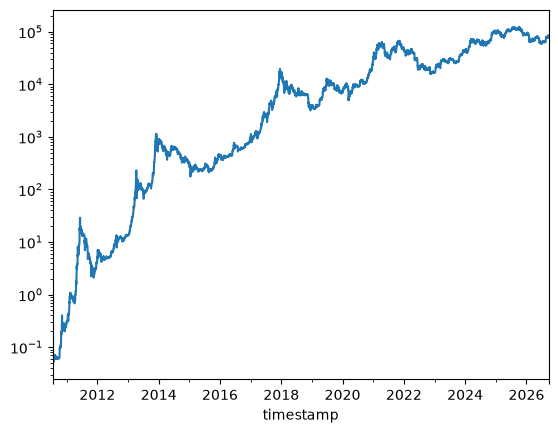

In [2]:
import pandas as pd
from finlab_crypto import onchain

btc = onchain.coinmetrics(['PriceUSD', 'IssTotUSD'])
close = btc.PriceUSD.dropna()
close.plot(logy=True)

In [3]:
HALVINGS = {'2009-01-03': 50, '2012-11-28': 25, '2016-07-09': 12.5, '2020-05-11': 6.25, '2024-04-20': 3.125}
BLOCKS_PER_DAY = 144
PUELL_WINDOW = 365

reward = pd.Series(HALVINGS)
reward.index = pd.to_datetime(reward.index, utc=True)
reward = reward.reindex(close.index, method='ffill')
daily_value_mined = reward * close * BLOCKS_PER_DAY
puell_multiple = daily_value_mined / daily_value_mined.rolling(PUELL_WINDOW).mean()

mindicator = puell_multiple.resample('ME').last().dropna()
mclose = close.resample('ME').last().reindex(mindicator.index)
mpct_change = mclose.pct_change().fillna(0) + 1

## 回測函式

`rule(indicator, position)` 回傳這個月要投入（正）或賣出（負）的金額。

In [4]:
def simulate(rule):
    position, invested, withdrawn = 0.0, 0.0, 0.0
    history = []
    for pct_change, ind in zip(mpct_change, mindicator):
        position *= pct_change
        delta = rule(ind, position)
        position += delta
        invested += max(delta, 0)
        withdrawn += max(-delta, 0)
        history.append({'position': position, 'invested': invested, 'withdrawn': withdrawn})
    result = pd.DataFrame(history, index=mclose.index)
    result['profit'] = result.position + result.withdrawn - result.invested
    return result

In [5]:
MONTHLY_BUDGET = 10000


def dollar_cost_averaging(ind, position):
    return MONTHLY_BUDGET


def my_rule(ind, position):
    # TODO: 設計你的規則，例如越便宜買越多
    if ind < 1:
        return MONTHLY_BUDGET * 2
    if ind < 3:
        return MONTHLY_BUDGET
    return -0.1 * position

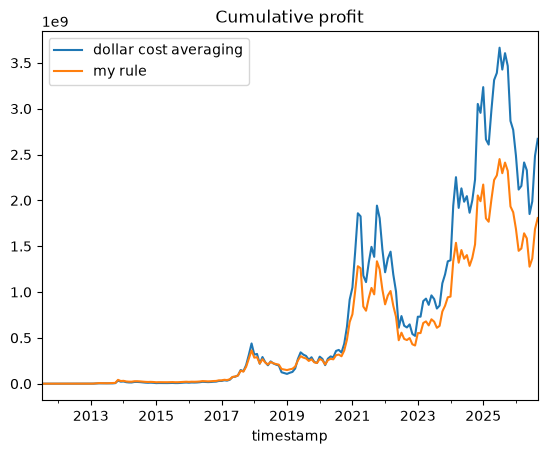

In [6]:
import matplotlib.pyplot as plt

# 圖表文字用英文：Colab 預設字型沒有中文字
pd.DataFrame({
    'dollar cost averaging': simulate(dollar_cost_averaging).profit,
    'my rule': simulate(my_rule).profit,
}).plot(title='Cumulative profit')
plt.show()

## 你的觀察

你的規則在哪些時期贏過定期定額？投入的總成本差多少？